In [1]:
import os
import sys
import copy
import cantera as ct
import numpy as np
import pandas as pd
import concurrent.futures
import subprocess

import matplotlib.pyplot as plt
%matplotlib inline

sys.path.append('/home/moon/autoscience/autoscience_workflow/analysis/')
# sys.path.append(os.path.join(os.path.dirname(os.environ['DFT_DIR']), 'analysis'))
import ignition_delay


In [2]:
fuel_yaml = '/home/moon/autoscience/dib/DIB_MAX_1/DIB_MAX2.yaml'
gas = ct.Solution(fuel_yaml)

/home/moon/anaconda3/envs/rmg_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: Chebyshev reaction equation: Specifying '(+M)' in the reaction equation for Chebyshev reactions is deprecated.
On line 2487 of /home/moon/autoscience/dib/DIB_MAX_1/DIB_MAX2.yaml:
|  Line |
|  2482 |   rate-constant: {A: 1.41e+05, b: 1.836, Ea: 19.82}
|  2483 |   note: |-
|  2484 |     Reaction index: Chemkin #83; RMG #83
|  2485 |     Library reaction: CurranPentane
|  2486 |     Flux pairs: IC4H7O2(386), IC4H6OOH-I(387);
>  2487 > - equation: C[C]1CC1(721) (+M) <=> IC4H7(282) (+M)  # Reaction 84
            ^
|  2488 |   type: Chebyshev
|  2489 |   temperature-range: [300.0, 2000.0]
|  2490 |   pressure-range: [0.01 atm, 98.692 atm]

  


In [3]:
# Load the experimental conditions
ignition_delay_data = '/work/westgroup/harris.se/autoscience/reaction_calculator/experiment/dib_ignition_delay.csv'
ignition_delay_data = '/home/moon/autoscience/autoscience_workflow/experiment/dib_ignition_delay.csv'

df_exp = pd.read_csv(ignition_delay_data)

# grab just the Metcalfe 2007 DIB phi=0.5 data P=4 atm (table 24)
ref_table = df_exp[df_exp['Table'] == 24]

# Define Initial conditions using experimental data
taus = ref_table['Time (ms)'].values.astype(float)  # ignition delay
Ts = ref_table['T (K)'].values  # Temperatures
Ps = ref_table['Pressure (bar)'].values * 1e5 / ct.one_atm  # pressures in atm
phi = ref_table['Phi'].values[0]
author = ref_table['Author'].values[0]

# list of starting conditions
concentrations = []
conc_dict = {
    'DIB1(1)': ref_table['DIB1'].values[0],
    'DIB2(2)': ref_table['DIB2'].values[0],
    'O2(3)': ref_table['O2'].values[0],
    'Ar': ref_table['Ar'].values[0]
}
concentrations = [conc_dict for i in range(len(ref_table))]

# Plot Individual Ignition Delays

no ignition detected


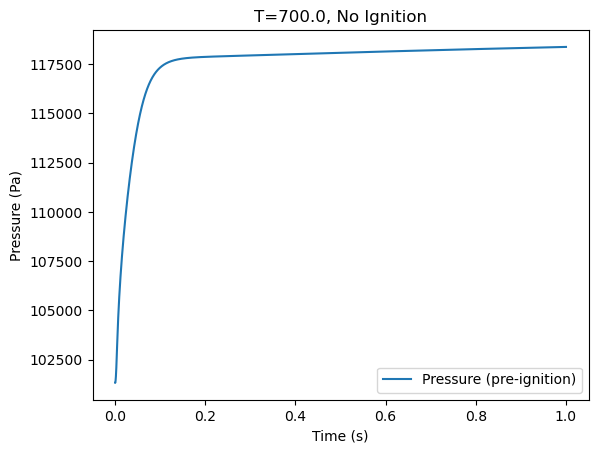

no ignition detected


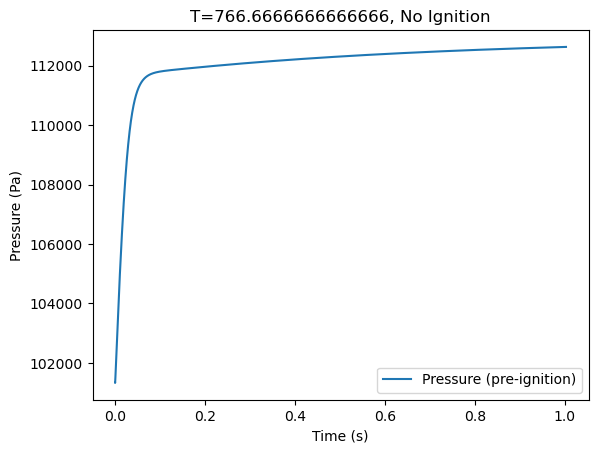

no ignition detected


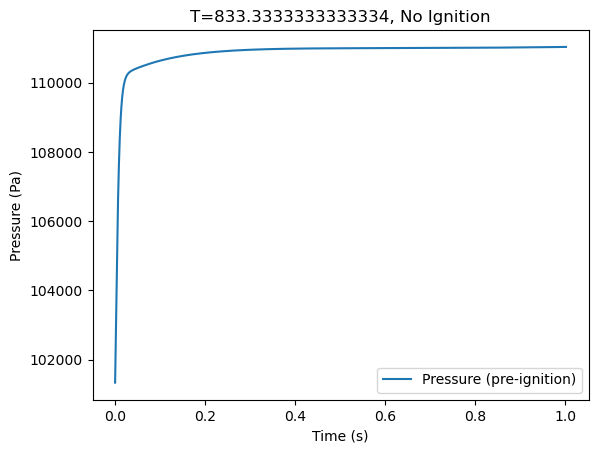

no ignition detected


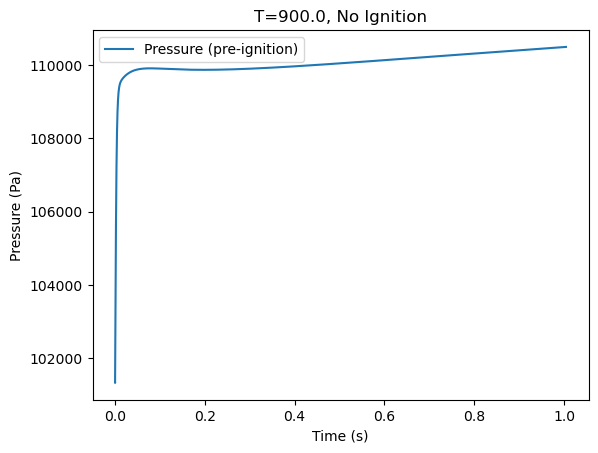

no ignition detected


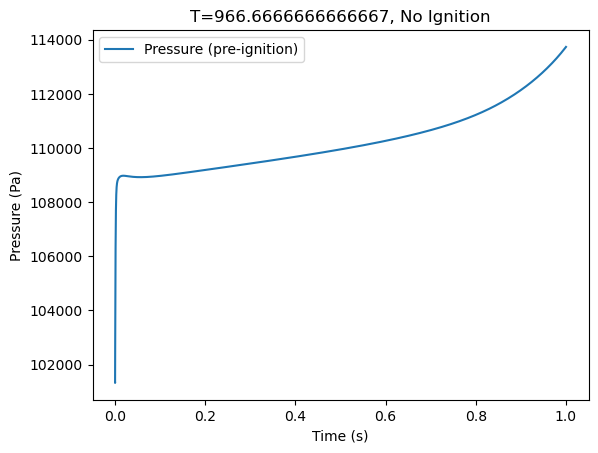

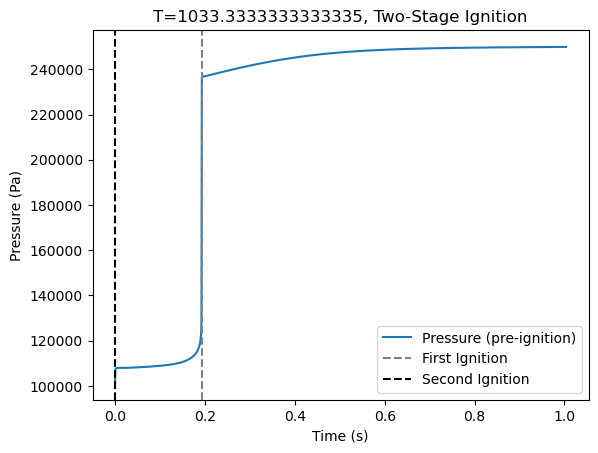

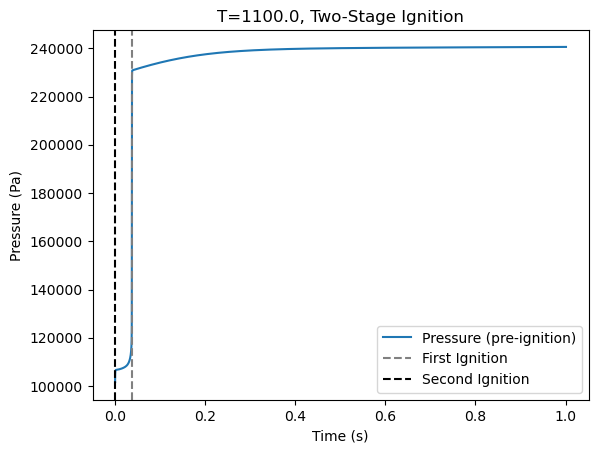

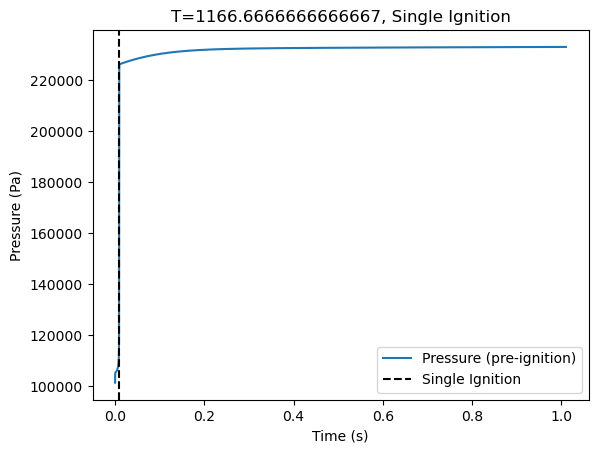

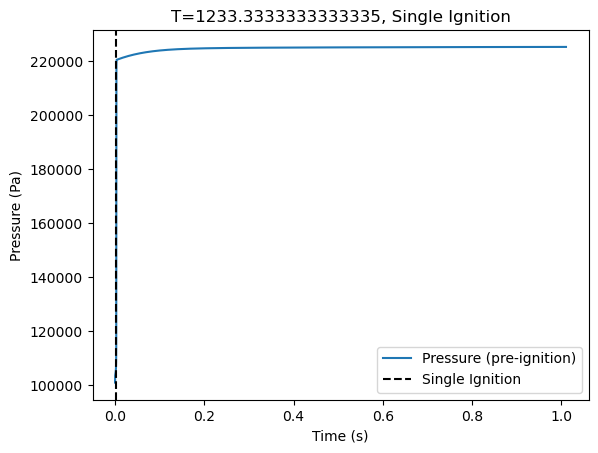

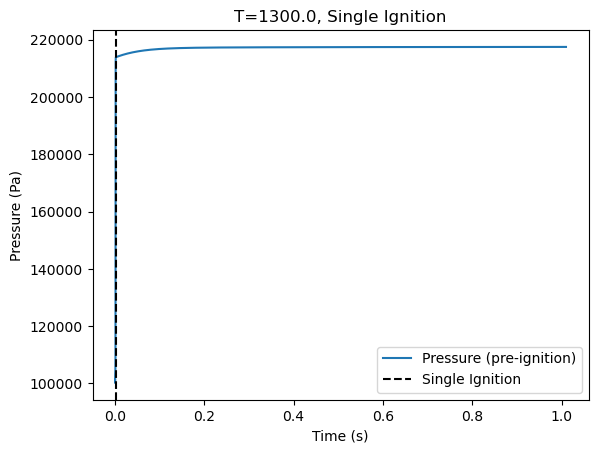

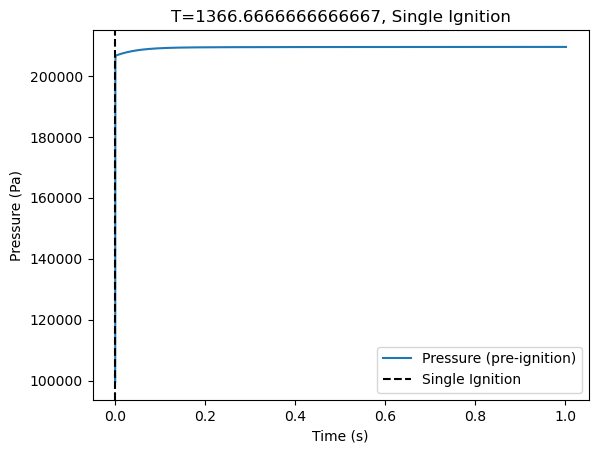

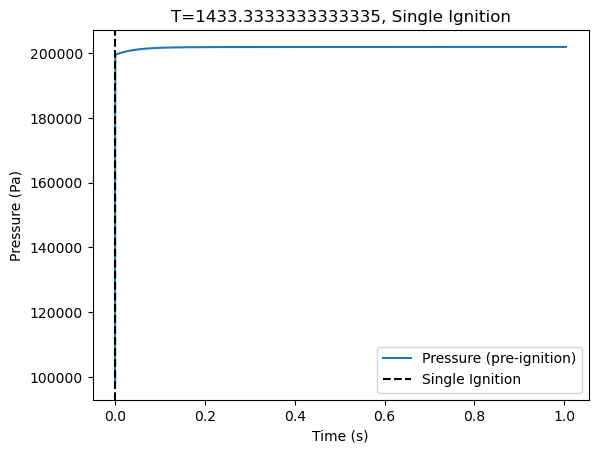

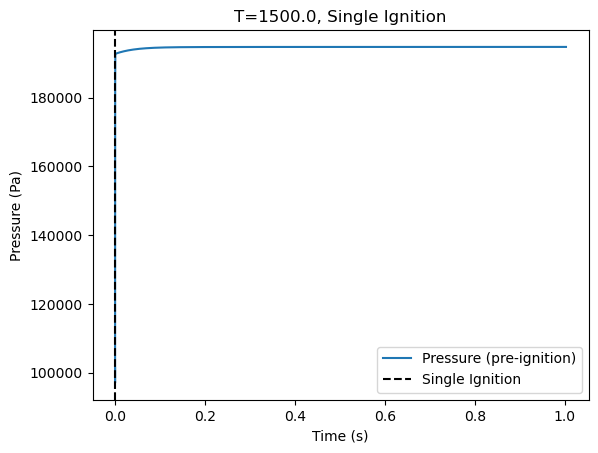

In [5]:
for T_start in np.linspace(700, 1500, 13):
    P_start = 101325
    X_start = conc_dict

    # function to run a RCM simulation

    t_end = 1.0  # time in seconds
    gas.TPX = T_start, P_start, X_start

    env = ct.Reservoir(ct.Solution('air.yaml'))
    reactor = ct.IdealGasReactor(gas)
    wall = ct.Wall(reactor, env, A=1.0, velocity=0)
    reactor_net = ct.ReactorNet([reactor])

    times = [0]
    T = [reactor.T]
    P = [reactor.thermo.P]
    X = [reactor.thermo.X]  # mol fractions
    while reactor_net.time < t_end:
        reactor_net.step()

        times.append(reactor_net.time)
        T.append(reactor.T)
        P.append(reactor.thermo.P)
        X.append(reactor.thermo.X)

    t1, t2 = ignition_delay.get_ignition_delays(times, P)

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    plt.plot(times, P, color=colors[0], label='Pressure (pre-ignition)')
    plt.ylabel('Pressure (Pa)')
    plt.xlabel('Time (s)')
    if t1 > 0 and t2 == -1:
        plt.axvline(x=t1, color='black', linestyle='--', label='Single Ignition')
        plt.title(f'T={T_start}, Single Ignition')
    elif t1 > 0 and t2 > 0:
        plt.axvline(x=t1, color='grey', linestyle='--', label='First Ignition')
        plt.axvline(x=t2, color='black', linestyle='--', label='Second Ignition')
        plt.title(f'T={T_start}, Two-Stage Ignition')
    else:
        plt.title(f'T={T_start}, No Ignition')
#     plt.xscale('log')
    plt.legend()
    plt.show()

# Plot curve of ignition delays

In [6]:
temperatures = np.linspace(700, 1500, 21)
delays = np.zeros((len(temperatures), 2))

# for T_start in np.linspace(700, 1500, 13):
for j in range(len(temperatures)):
    T_start = temperatures[j]
    P_start = 101325
    X_start = conc_dict

    # function to run a RCM simulation

    t_end = 1.0  # time in seconds
    gas.TPX = T_start, P_start, X_start

    env = ct.Reservoir(ct.Solution('air.yaml'))
    reactor = ct.IdealGasReactor(gas)
    wall = ct.Wall(reactor, env, A=1.0, velocity=0)
    reactor_net = ct.ReactorNet([reactor])

    times = [0]
    T = [reactor.T]
    P = [reactor.thermo.P]
    X = [reactor.thermo.X]  # mol fractions
    while reactor_net.time < t_end:
        reactor_net.step()

        times.append(reactor_net.time)
        T.append(reactor.T)
        P.append(reactor.thermo.P)
        X.append(reactor.thermo.X)

    t1, t2 = ignition_delay.get_ignition_delays(times, P)
    delays[j, 0] = t1
    delays[j, 1] = t2


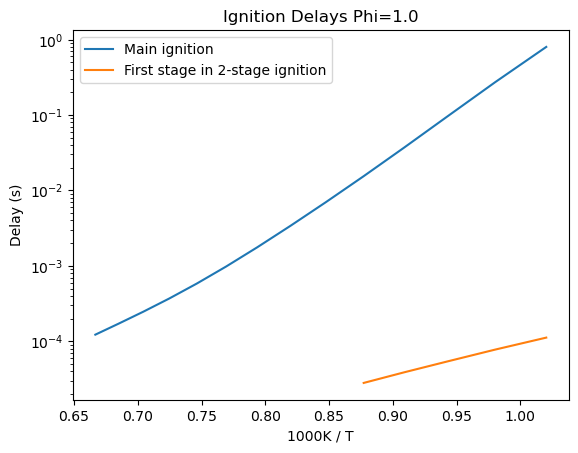

In [10]:
delays[delays == -1] = np.nan
plt.plot(1000 / temperatures, delays[:, 0], label='Main ignition')
plt.plot(1000 / temperatures, delays[:, 1], label='First stage in 2-stage ignition')

ax = plt.gca()
ax.set_yscale('log')
plt.title('Ignition Delays Phi=1.0')
plt.xlabel('1000K / T')
plt.ylabel('Delay (s)')
plt.legend()